In [1]:
from sys import stdout

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 设置显示中文字体，
from pylab import mpl
import math
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  ## mac
plt.rcParams['font.family'] = ['Arial Unicode MS']  ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警
from scipy.signal import savgol_filter

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Absorbance data, collected in the matrix X
data=pd.read_excel(r"/Users/macbook/folder/data/pre/mscFLMA_.xlsx").values
X = data[:,1:]
y = data[:,0]
wl = np.linspace(942, 1701, X.shape[1])

In [3]:
# Define the PLS regression object
pls = PLSRegression(n_components=8)
# Fit data
pls.fit(X, y)

# Plot spectra
# plt.figure(figsize=(12,14))
# with plt.style.context(()):
#     ax1 = plt.subplot(211)
#     plt.plot(wl, X.T)
#     plt.text(910, 0.51, "(a)\n\n", fontsize=16, color='black') 
#     plt.xticks(fontsize=16)  
#     plt.yticks(fontsize=16)
#     plt.ylabel('反射率', fontsize=18)
# 
#     ax2 = plt.subplot(212, sharex=ax1)
#     plt.plot(wl, np.abs(pls.coef_[:,0]))
#     plt.xticks(fontsize=16)  
#     plt.yticks(fontsize=16)
#     plt.xlabel('波长 (nm)', fontsize=18)
#     plt.ylabel('Absolute value of PLS coefficients', fontsize=18)
# 
#     plt.show()

PLSRegression(n_components=8)

In [4]:
# Get VIP scores
W = pls.x_weights_
T = pls.x_scores_
P = pls.x_loadings_
Q = pls.y_loadings_
V = np.dot(np.dot(P, np.diag(1/np.diag(np.dot(P.T, P)))), P.T)
V = np.dot(V, W)
s = np.diag(np.dot(np.dot(T.T, T), np.dot(W.T, W)))
s_vip = np.sqrt(len(s)*s/np.sum(s))
vip_scores = np.dot(V**2, s_vip)

# # plot VIP scores and spectra on the same figure在同一个图上绘制VIP分数和光谱
# fig, ax1 = plt.subplots(figsize=(10, 6))
# 
# # plot VIP scores画VIP分数
# color = 'tab:red'
# ax1.bar(wl, vip_scores, color=color, alpha=0.5)
# ax1.set_xlabel('Wavelength (nm)')
# ax1.set_ylabel('VIP score', color=color)
# ax1.tick_params(axis='y', labelcolor=color)
# ax1.set_ylim([0, max(vip_scores)*1.1])
# 
# # plot spectra画光谱
# ax2 = ax1.twinx()
# color = 'tab:blue'
# for i in range(X.shape[0]):
#     ax2.plot(wl, X[i, :], alpha=0.5, color=color)
# 
# ax2.set_ylabel('Derivative of the Spectral intensity', color=color)
# ax2.tick_params(axis='y', labelcolor=color)
# ax2.set_ylim([min(X.flatten()), max(X.flatten())*1.1])
# 
# plt.title('VIP scores and Spectra')
# plt.show()

In [5]:
data=pd.read_excel(r"/Users/macbook/folder/data/pre/mscFLMA_.xlsx").values
X1 = data[:,1:]
# 读取数据
data1 = pd.read_excel("/Users/macbook/folder/data/FL199.xlsx")
X1 = data1.values[:, 1:]

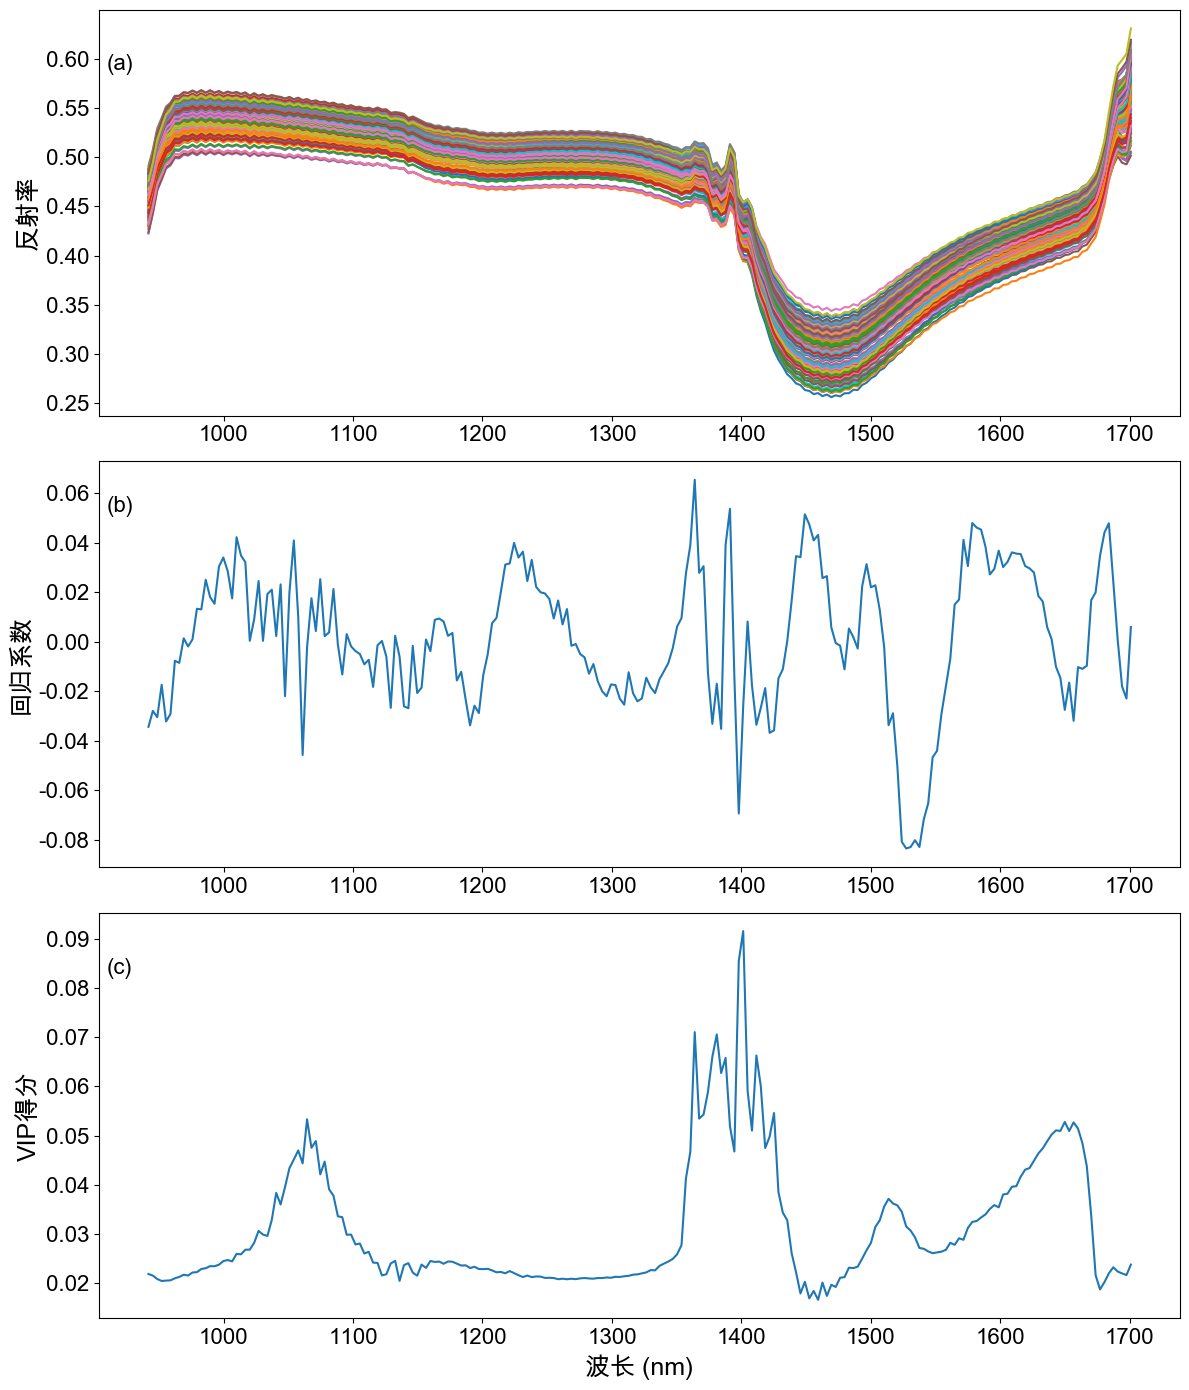

In [6]:
# Plot spectra
fig=plt.figure(figsize=(12,14))
with plt.style.context(()):
    ax1 = plt.subplot(311)
    plt.plot(wl, X1.T)
    plt.text(910, 0.54, "(a)\n\n", fontsize=16, color='black') 
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16)
    plt.ylabel('反射率', fontsize=18)
    
    ax2 = plt.subplot(312, sharex=ax1)
    plt.plot(wl, pls.coef_[:,0])
    plt.text(910, 0.033, "(b)\n\n", fontsize=16, color='black') 
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16)
    # plt.xlabel('Wavelength (nm)', fontsize=18)
    plt.ylabel('回归系数', fontsize=18)

    ax3 = plt.subplot(313, sharex=ax1)
    plt.plot(wl, vip_scores)
    plt.text(910, 0.073, "(c)\n\n", fontsize=16, color='black') 
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16)
    plt.xlabel('波长 (nm)', fontsize=18)
    plt.ylabel('VIP得分', fontsize=18)
    # 调整布局
    plt.tight_layout()
    # # 保存为TIFF格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图4.tif', format='tiff', dpi=300, bbox_inches='tight')
    # # 保存为JPG格式
    # plt.savefig('/Users/macbook/Desktop/论文原图/图4.jpg', format='jpg', dpi=300, bbox_inches='tight')
    
    plt.savefig('/Users/macbook/Desktop/论文11_24/图4.svg')
    plt.savefig('/Users/macbook/Desktop/论文11_24/图4.eps',format='eps')
    plt.savefig('/Users/macbook/Desktop/论文11_24/图4.pdf',format='pdf')
    plt.show() 

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# path='H:'#图片输出路径
# fig=plt.figure()#创建画板
# ax=fig.add_subplot()
# x1 = np.linspace(0, 10, 50)
# y1 =(x1*x1)
# ax.plot(x1,y1,label='y=x$^2$')
# ax.legend()#添加图例
# fig.savefig(path+'输出图片.svg',format='svg',dpi=150)#输出

In [8]:
pls.coef_[:,0]

array([-0.03439293, -0.02794402, -0.03050489, -0.01739808, -0.03222397,
       -0.02922373, -0.00769576, -0.00853207,  0.00140397, -0.00190524,
        0.00098265,  0.01333483,  0.01307726,  0.02506509,  0.01804979,
        0.01534637,  0.03035312,  0.03406413,  0.02849618,  0.01750895,
        0.04225127,  0.03490508,  0.03211876,  0.00038952,  0.00911471,
        0.02454647,  0.0003533 ,  0.01927172,  0.02103517,  0.00232564,
        0.02319345, -0.02202031,  0.01988211,  0.04094386,  0.00993483,
       -0.04576263, -0.00229677,  0.017589  ,  0.00432393,  0.02529344,
        0.00226893,  0.00379451,  0.02131221, -0.00115524, -0.01323077,
        0.00309223, -0.00189559, -0.00377694, -0.00497624, -0.00913694,
       -0.00726596, -0.01825035, -0.0014201 ,  0.00032193, -0.00598477,
       -0.02672013,  0.00240873, -0.006002  , -0.02609386, -0.02686997,
       -0.0016599 , -0.02071502, -0.01855   ,  0.0009234 , -0.00378583,
        0.00889316,  0.00938   ,  0.00817273,  0.00237369,  0.00